## Substitutions

## Process results

In [15]:
import pandas as pd

def process_data(csv_path="./simulation_outputs/substitutions"):
    df = pd.read_csv(csv_path + "/simulation_summary.csv")

    numeric_cols = [
        "CV MSE Mean", "CV MSE Std", "Test MSE Mean", "Test MSE Std",
        "Test RMSE Mean", "Test RMSE Std", "Test MAE Mean", "Test MAE Std",
        "Test R2 Mean", "Test R2 Std", "Test Spearman Correlation Mean",
        "Test Spearman Correlation Std", "Top 20 Accuracy Mean",
        "Top 20 Accuracy Std"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Make name shorter
    df.loc[df["Model"] == "GaussianProcessRegressor", "Model"] = "GPR"

    # Add simplified foundation column for grouping
    df["Foundation Simple"] = df.apply(
        lambda row: (" + ESM2 (SCARSE)" if not row['Baseline'] else " + Descriptors (Baseline)"),
        axis=1
    )

    df["Model Label"] = (
        df.apply(
            lambda row: f"{row['Model']}" + row['Foundation Simple'],
            axis=1
        )
    )

    df.to_csv(csv_path + "/simulation_summary_processed.csv", index=False)

In [16]:
process_data(csv_path="./simulation_outputs/substitutions")

## Visualize

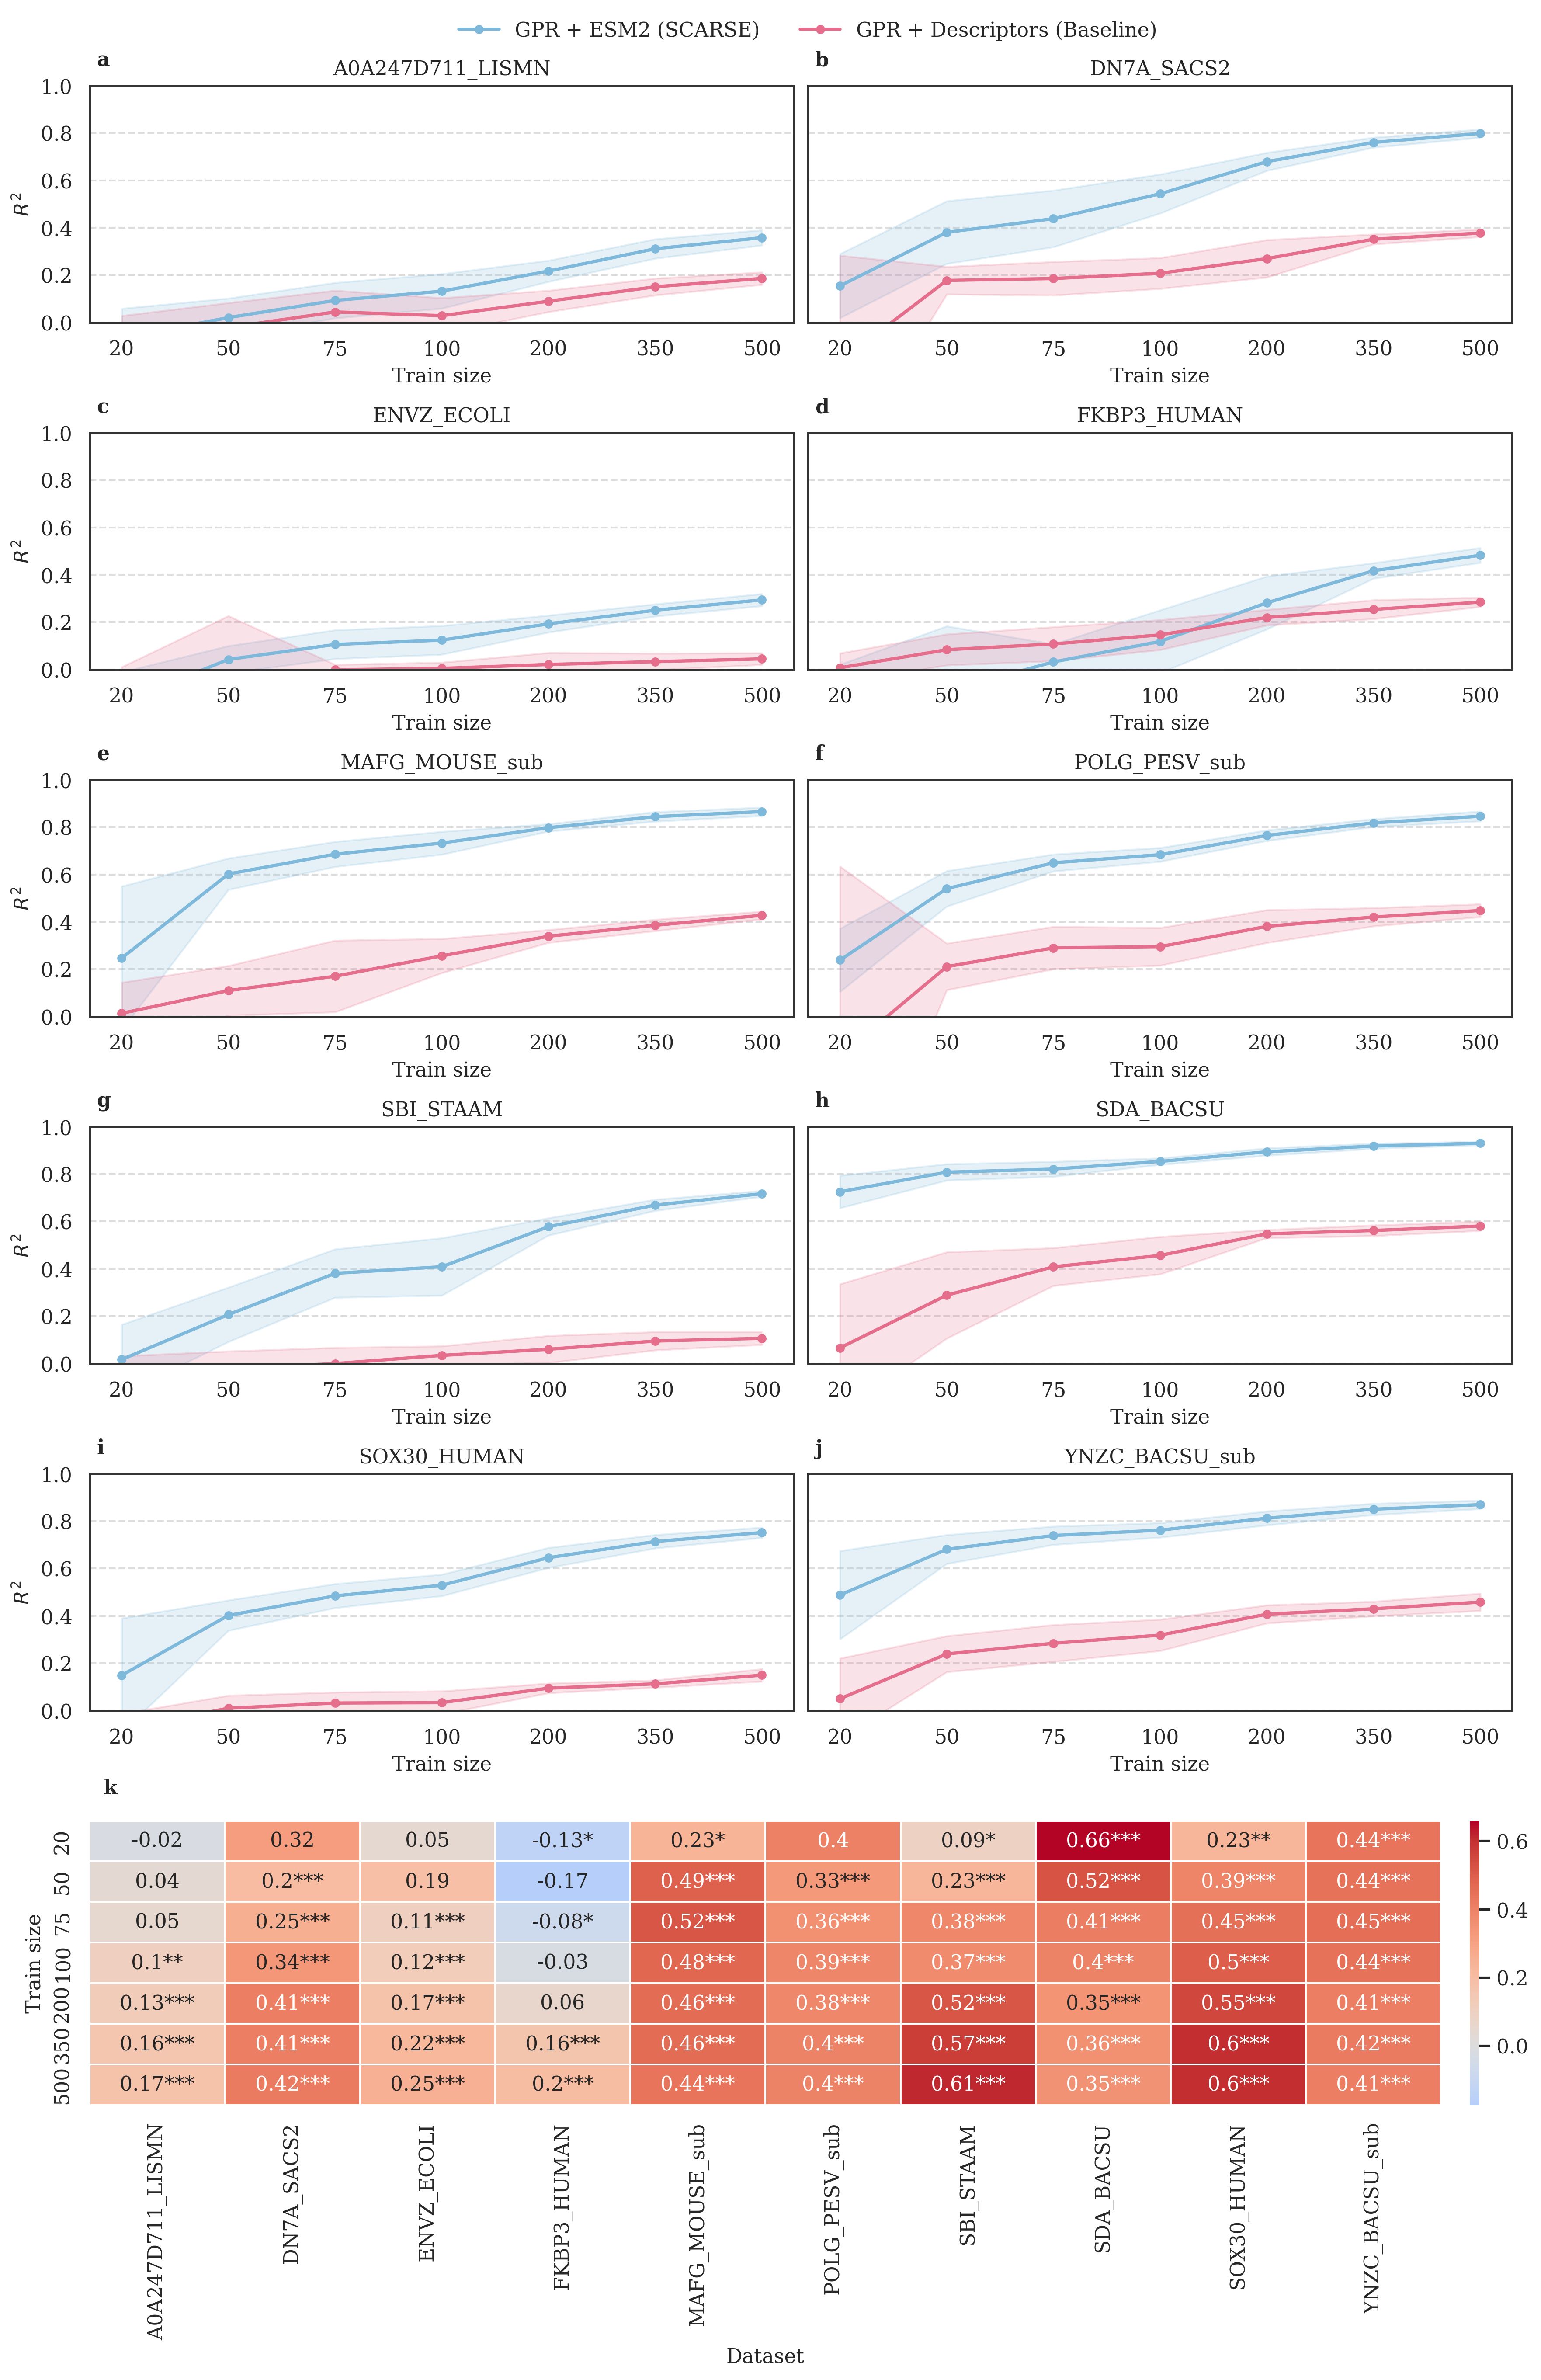

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import string

# =========================
# Styling
# =========================
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# =========================
# Load + filter
# =========================
metric = "Test R2"

df = pd.read_csv("./simulation_outputs/substitutions/simulation_summary_processed.csv")

models_of_interest = ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"]

df = df[df["Model Label"].isin(models_of_interest)]

df = (
    df
    .groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
    .agg(
        mean=(f"{metric} Mean", "mean"),
        std=(f"{metric} Std", "mean")
    )
)

# =========================
# Dataset mapping
# =========================
dataset_names = [
    "A0A247D711_LISMN",
    "DN7A_SACS2",
    "ENVZ_ECOLI",
    "FKBP3_HUMAN",
    "MAFG_MOUSE_sub",
    "POLG_PESV_sub",
    "SBI_STAAM",
    "SDA_BACSU",
    "SOX30_HUMAN",
    "YNZC_BACSU_sub"
]

file_names = [
    "A0A247D711_LISMN_Stadelmann_2021",
    "DN7A_SACS2_Tsuboyama_2023_1JIC",
    "ENVZ_ECOLI_Ghose_2023",
    "FKBP3_HUMAN_Tsuboyama_2023_2KFV",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V",
    "POLG_PESV_Tsuboyama_2023_2MXD",
    "SBI_STAAM_Tsuboyama_2023_2JVG",
    "SDA_BACSU_Tsuboyama_2023_1PV0",
    "SOX30_HUMAN_Tsuboyama_2023_7JJK",
    "YNZC_BACSU_Tsuboyama_2023_2JVD"
]

dataset_short = dict(zip(file_names, dataset_names))

datasets = sorted(df["Dataset"].unique())
train_sizes = sorted(df["Train Size"].unique())

x_pos = np.arange(len(train_sizes))

# =========================
# Layout
# =========================
n_cols = 2
n_rows = 5

fig = plt.figure(figsize=(14, 20))

gs = GridSpec(
    n_rows + 1,
    n_cols,
    height_ratios=[1]*n_rows + [1.2],
    hspace=0.45,
    wspace=0.02
)

# =========================
# Colors
# =========================
color_gpr = "#7eb9db"
color_desc = "#e56e8c"

letters = list(string.ascii_lowercase)

# =========================
# LINE PLOTS (WITH STD BAND)
# =========================
for i, dataset in enumerate(datasets):

    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])

    ax.text(
        0.01, 1.15,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left"
    )

    for j, model in enumerate(models_of_interest):

        d = (
            df[
                (df["Dataset"] == dataset) &
                (df["Model Label"] == model)
            ]
            .set_index("Train Size")
            .reindex(train_sizes)
            .reset_index()
        )

        y = d["mean"].values
        yerr = d["std"].values

        color = color_gpr if j == 0 else color_desc

        # 🔥 USE x_pos instead of train_sizes
        ax.plot(
            x_pos,
            y,
            marker='o',
            linewidth=1.8,
            markersize=4,
            color=color,
            label=model if i == 0 else None
        )

        ax.fill_between(
            x_pos,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2
        )

    ax.set_title(dataset_short.get(dataset, dataset))
    ax.set_ylim(0, 1)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(train_sizes)

    ax.set_xlabel("Train size")

    if col == 0:
        ax.set_ylabel(r"$R^2$")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if col == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            labels,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(1.02, 1.35)
        )

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

# =========================
# HEATMAP (UNCHANGED)
# =========================
stats = pd.read_csv("statistics/results/substitutions_results.csv")
stats = stats[stats["Metric"] == metric].copy()

dataset_short = dict(zip(file_names, dataset_names))
stats["Dataset"] = stats["Dataset"].map(dataset_short)

def significance_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    return ""

stats["signif"] = stats["p-adj"].apply(significance_stars)

effect = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="effect size"
)

signif = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="signif",
    aggfunc="first"
)

effect = effect.reindex(train_sizes)
effect = effect[sorted(effect.columns)]

annot = effect.round(2).astype(str) + signif.fillna("")

ax_heat = fig.add_subplot(gs[n_rows, :])

ax_heat.text(
    0.01, 1.15,
    letters[len(datasets)],
    transform=ax_heat.transAxes,
    fontsize=11,
    fontweight="bold",
    va="top",
    ha="left"
)

effect_capped = effect.clip(upper=0.7)

sns.heatmap(
    effect_capped,
    ax=ax_heat,
    cmap="coolwarm",
    center=0,
    annot=annot,
    fmt="",
    linewidths=0.5,
    cbar_kws={
        "fraction": 0.03,
        "pad": 0.02,
        "aspect": 30
    }
)

ax_heat.set_xlabel("Dataset")
ax_heat.set_ylabel("Train size")

plt.show()

In [18]:
process_data(csv_path="./simulation_outputs/mbc")

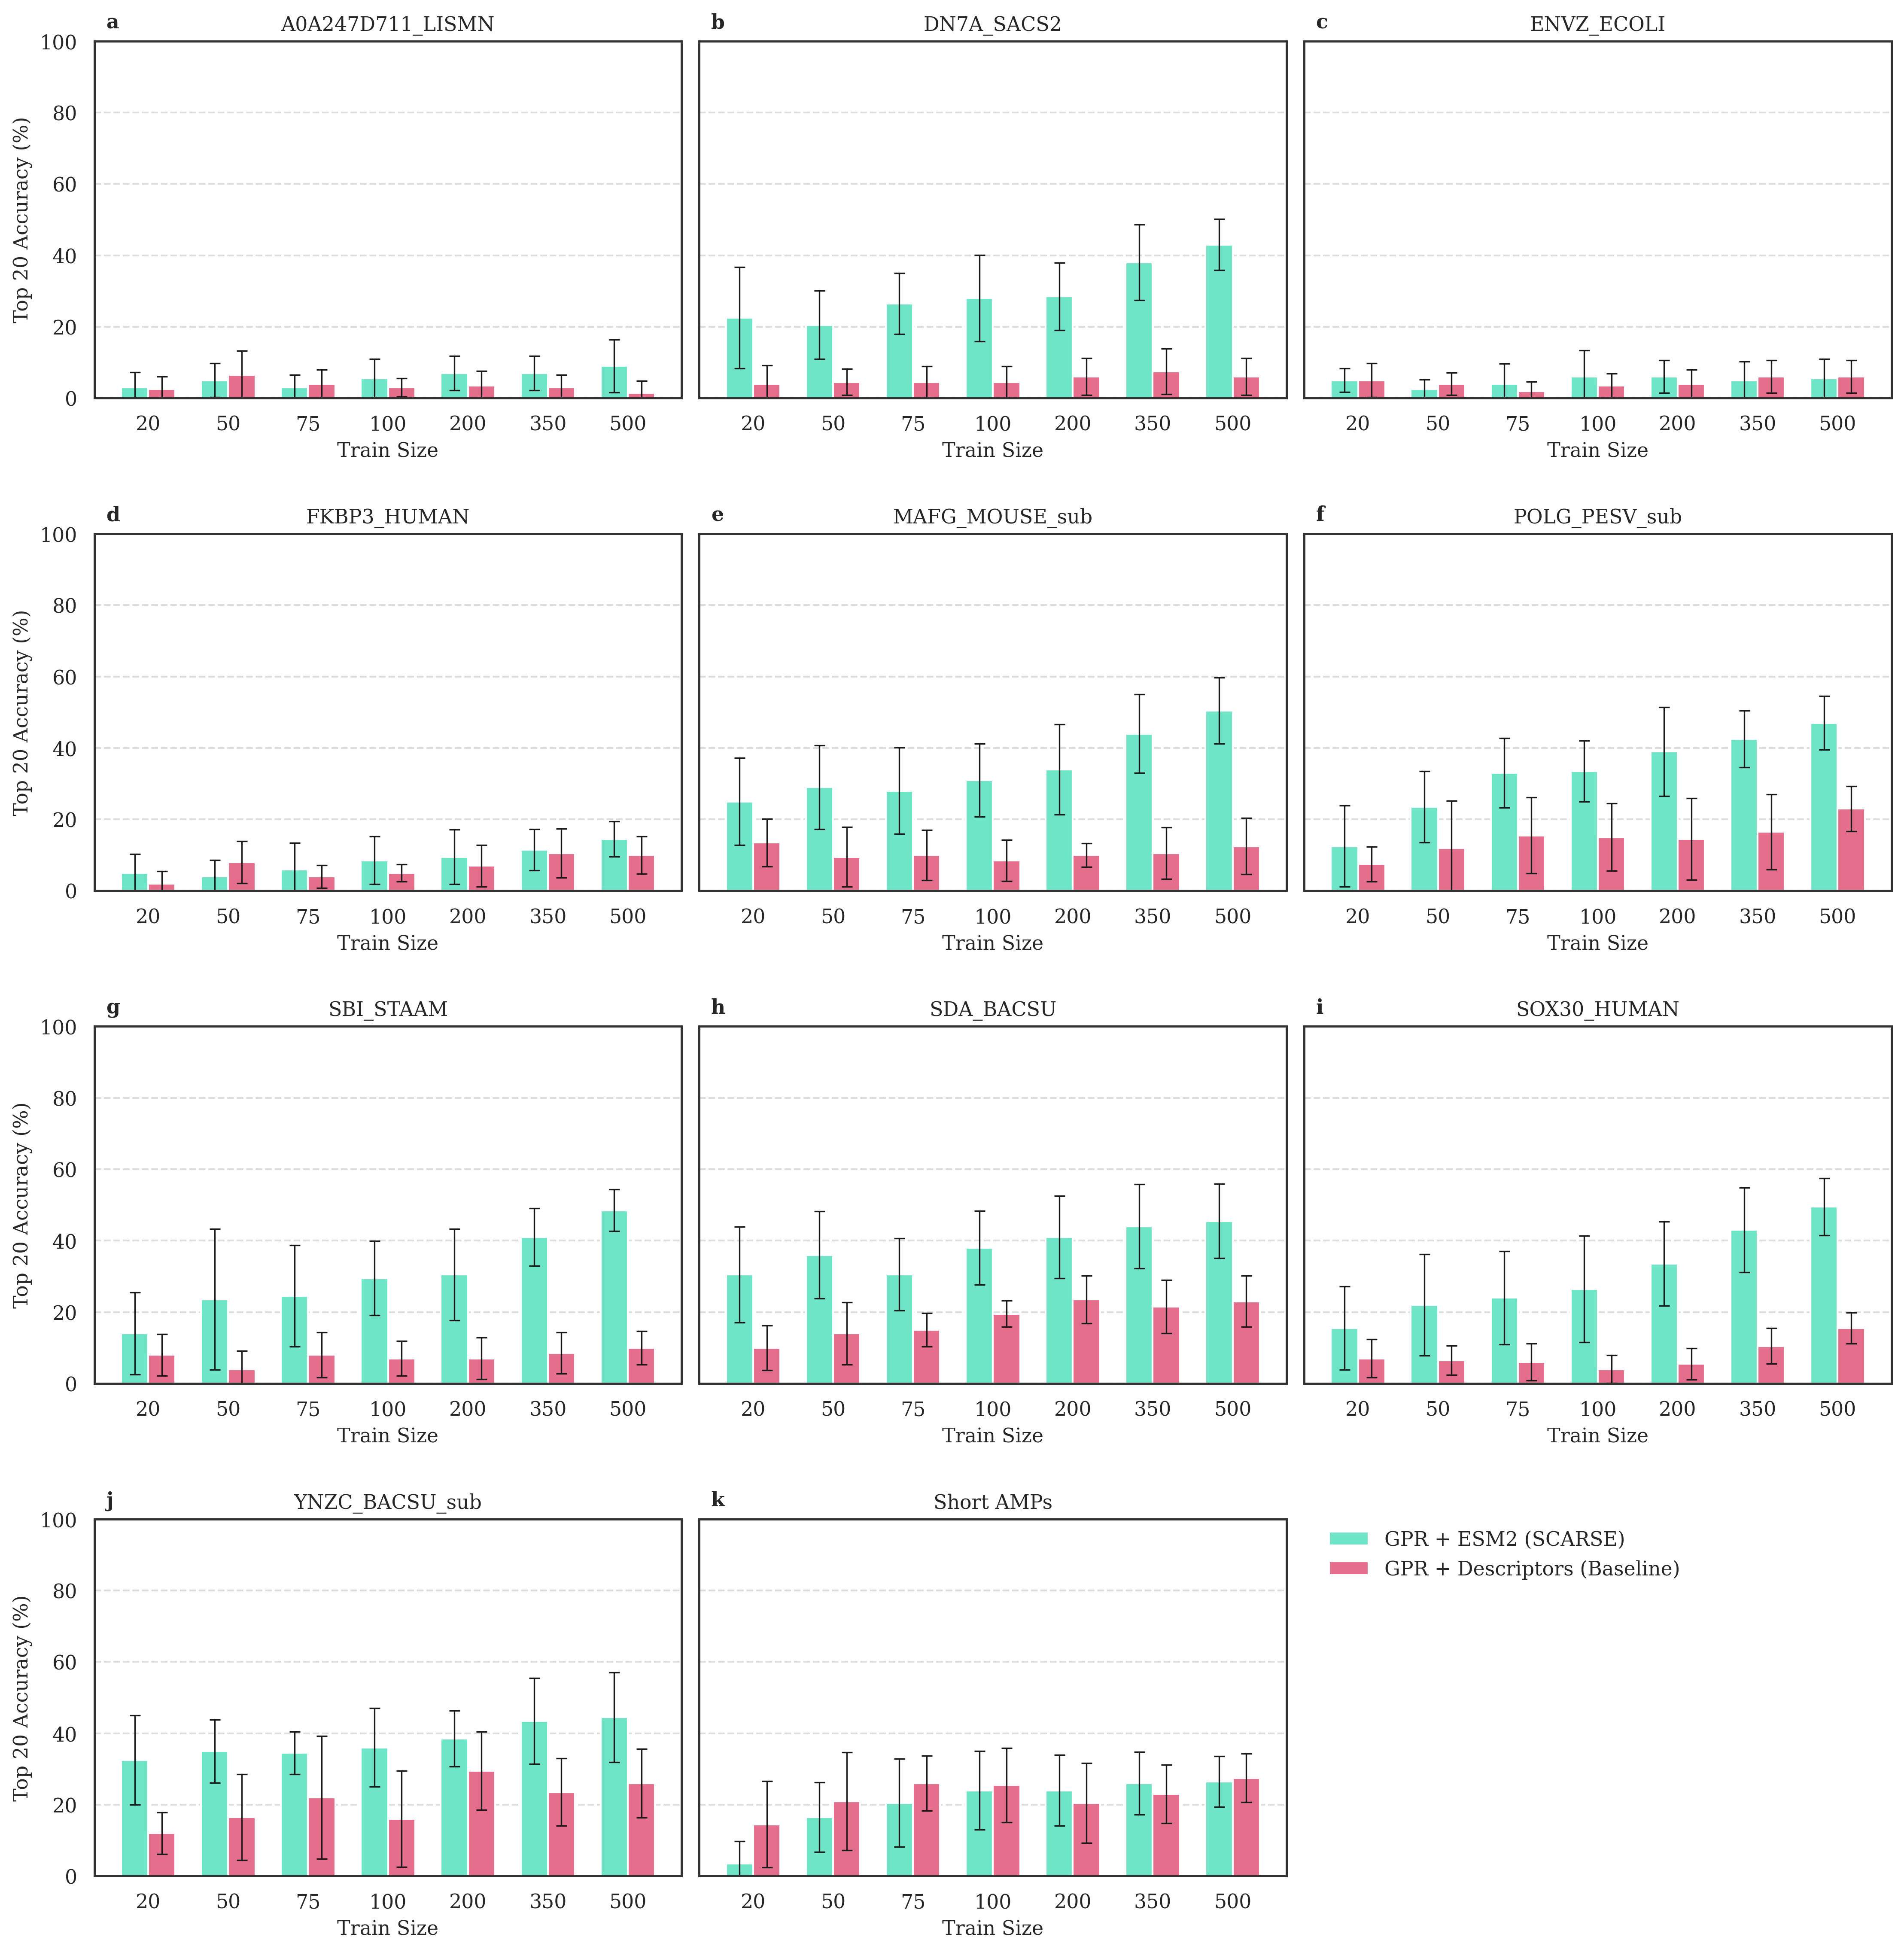

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import string

# ======================================================
# Styling (EXACTLY like your previous settings)
# ======================================================
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# ======================================================
# Load + filter
# ======================================================
metric = "Top 20 Accuracy"

df = pd.read_csv("./simulation_outputs/substitutions/simulation_summary_processed.csv")
df_mbc = pd.read_csv("./simulation_outputs/mbc/simulation_summary_processed.csv")
df = pd.concat([df, df_mbc], ignore_index=True)

models_of_interest = ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"]

df = df[df["Model Label"].isin(models_of_interest)]

df = (
    df
    .groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
    .agg(
        mean=(f"{metric} Mean", "mean"),
        std=(f"{metric} Std", "mean")
    )
)

# ------------------------------------------------------
# Short dataset names for subplot titles
# ------------------------------------------------------

dataset_names = [
    "A0A247D711_LISMN",
    "DN7A_SACS2",
    "ENVZ_ECOLI",
    "FKBP3_HUMAN",
    "MAFG_MOUSE_sub",
    "POLG_PESV_sub",
    "SBI_STAAM",
    "SDA_BACSU",
    "SOX30_HUMAN",
    "YNZC_BACSU_sub",
    "Short AMPs"
]

file_names = ["A0A247D711_LISMN_Stadelmann_2021",
              "DN7A_SACS2_Tsuboyama_2023_1JIC",
              "ENVZ_ECOLI_Ghose_2023",
              "FKBP3_HUMAN_Tsuboyama_2023_2KFV",
              "MAFG_MOUSE_Tsuboyama_2023_1K1V",
              "POLG_PESV_Tsuboyama_2023_2MXD",
              "SBI_STAAM_Tsuboyama_2023_2JVG",
              "SDA_BACSU_Tsuboyama_2023_1PV0",
              "SOX30_HUMAN_Tsuboyama_2023_7JJK",
              "YNZC_BACSU_Tsuboyama_2023_2JVD",
              "EC"]

dataset_short = dict(zip(file_names, dataset_names))

datasets = file_names
train_sizes = sorted(df["Train Size"].unique())
x = np.arange(len(train_sizes))

# ======================================================
# Layout
# ======================================================
n_datasets = len(datasets)
n_cols = 3
n_rows = int(np.ceil(n_datasets / n_cols))

fig = plt.figure(figsize=(18, 6.5 + 3*n_rows))

gs = GridSpec(
    n_rows,
    n_cols,
    hspace=0.38,
    wspace=0.03
)

# ======================================================
# Colors
# ======================================================
color_gpr = "#6ee5c7"
color_desc = "#e56e8c"
bar_width = 0.34

letters = list(string.ascii_lowercase)

# ======================================================
# Dataset subplots
# ======================================================
for i, dataset in enumerate(datasets):

    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])

    ax.text(
        0.02, 1.08,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        fontfamily="DejaVu Serif",
        va="top",
        ha="left"
    )

    for j, model in enumerate(models_of_interest):

        d = (
            df[
                (df["Dataset"] == dataset) &
                (df["Model Label"] == model)
            ]
            .set_index("Train Size")
            .reindex(train_sizes)
            .reset_index()
        )

        offset = (-bar_width/2) if j == 0 else (bar_width/2)

        ax.bar(
            x + offset,
            d["mean"],
            yerr=d["std"],
            capsize=3,
            width=bar_width,
            color=color_gpr if j == 0 else color_desc,
            label=model if i == 0 else "",
            error_kw=dict(elinewidth=0.8, capthick=0.8),
        )

    # Shortened title
    ax.set_title(dataset_short.get(dataset, dataset))

    ax.set_ylim(0, 100)

    ax.set_xticks(x)
    ax.set_xticklabels(train_sizes)
    ax.set_xlabel("Train Size")
    #if row == n_rows - 1:
    #    ax.set_xticks(x)
    #    ax.set_xticklabels(train_sizes)
    #    ax.set_xlabel("Train Size")
    #elif row == n_rows - 2 and col in [2, 3]:
    #    ax.set_xticks(x)
    #    ax.set_xticklabels(train_sizes)
    #    ax.set_xlabel("Train Size")
    #else:
    #    ax.set_xticks([])

    if col == 0:
        ax.set_ylabel(r"Top 20 Accuracy (%)")
    else:
        ax.set_yticklabels([])

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

    # Shared legend (top center)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
    if row == n_rows - 1 and col == 1:
        
        ax.legend(
            handles,
            labels,
            loc="right",
            bbox_to_anchor=(1.7, 0.9),
            frameon=False
        )

plt.show()

# Indels

In [20]:
process_data(csv_path="./simulation_outputs/indels")

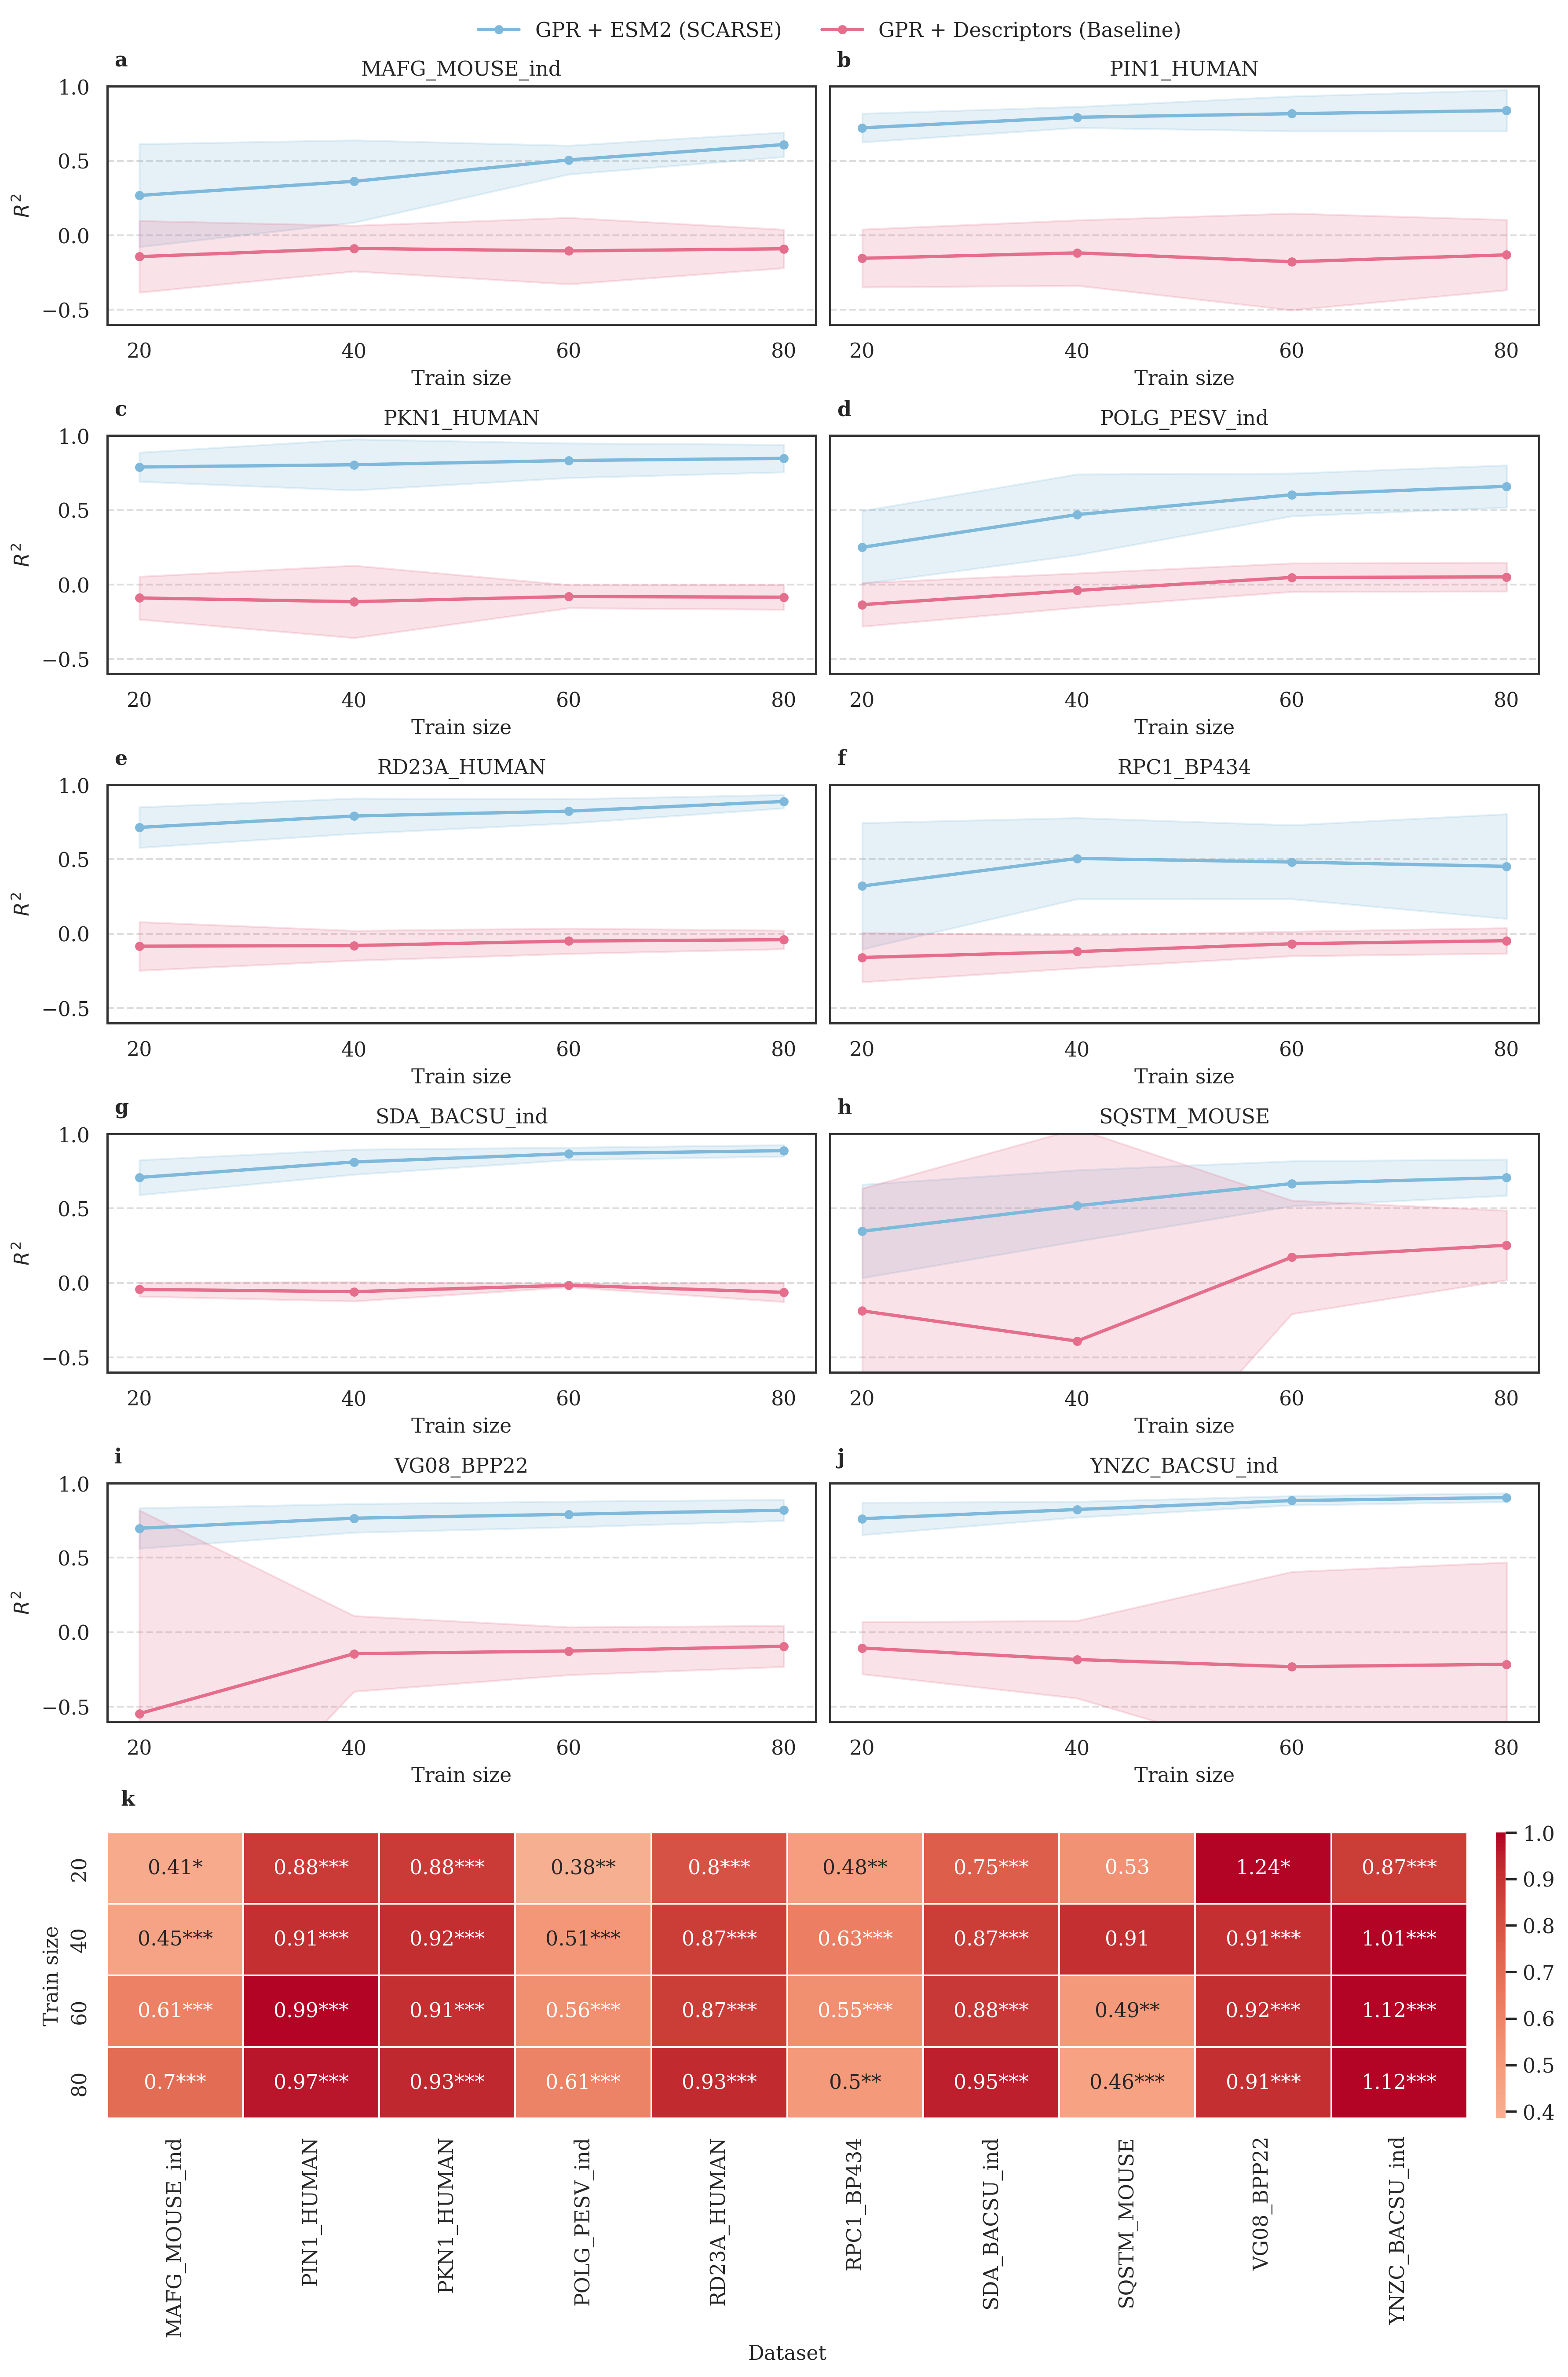

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import string

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

metric = "Test R2"

df = pd.read_csv("./simulation_outputs/indels/simulation_summary_processed.csv")

models_of_interest = ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"]

df = df[df["Model Label"].isin(models_of_interest)]

df = (
    df
    .groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
    .agg(
        mean=(f"{metric} Mean", "mean"),
        std=(f"{metric} Std", "mean")
    )
)

dataset_names = [
    "PKN1_HUMAN",
    "RPC1_BP434",
    "POLG_PESV_ind",
    "SDA_BACSU_ind",
    "RD23A_HUMAN",
    "MAFG_MOUSE_ind",
    "SQSTM_MOUSE",
    "VG08_BPP22",
    "YNZC_BACSU_ind",
    "PIN1_HUMAN"
]

file_names = [
    "PKN1_HUMAN_Tsuboyama_2023_1URF_indels",
    "RPC1_BP434_Tsuboyama_2023_1R69_indels",
    "POLG_PESV_Tsuboyama_2023_2MXD_indels",
    "SDA_BACSU_Tsuboyama_2023_1PV0_indels",
    "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels",
    "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels",
    "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels",
    "VG08_BPP22_Tsuboyama_2023_2GP8_indels",
    "YNZC_BACSU_Tsuboyama_2023_2JVD_indels",
    "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels"
]

dataset_short = dict(zip(file_names, dataset_names))

datasets = sorted(df["Dataset"].unique())
train_sizes = sorted(df["Train Size"].unique())

n_cols = 2
n_rows = 5

fig = plt.figure(figsize=(14, 20))

gs = GridSpec(
    n_rows + 1,
    n_cols,
    height_ratios=[1]*n_rows + [1.2],
    hspace=0.45,
    wspace=0.02
)

color_gpr = "#7eb9db"
color_desc = "#e56e8c"

letters = list(string.ascii_lowercase)

# =========================
# LINE PLOTS + SHADED STD
# =========================
for i, dataset in enumerate(datasets):

    row = i // n_cols
    col = i % n_cols
    ax = fig.add_subplot(gs[row, col])

    ax.text(
        0.01, 1.15,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        fontfamily="DejaVu Serif",
        va="top",
        ha="left"
    )

    x_vals = np.array(train_sizes)

    for j, model in enumerate(models_of_interest):

        d = (
            df[
                (df["Dataset"] == dataset) &
                (df["Model Label"] == model)
            ]
            .set_index("Train Size")
            .reindex(train_sizes)
            .reset_index()
        )

        y = d["mean"].values
        yerr = d["std"].values

        color = color_gpr if j == 0 else color_desc

        ax.plot(
            x_vals,
            y,
            marker='o',
            linewidth=1.8,
            markersize=4,
            color=color,
            label=model if i == 0 else None
        )

        ax.fill_between(
            x_vals,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2
        )

    ax.set_title(dataset_short.get(dataset, dataset))
    ax.set_ylim(-0.6, 1)
    ax.set_xticks(train_sizes)
    ax.set_xlabel("Train size")

    # ONLY LEFT COLUMN HAS Y LABEL
    if col == 0:
        ax.set_ylabel(r"$R^2$")
    else:
        ax.set_ylabel("")
        ax.set_yticklabels([])

    if col == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            handles,
            labels,
            loc="upper center",
            ncol=2,
            bbox_to_anchor=(1.02, 1.35)
        )

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

# =========================
# HEATMAP SECTION (UNCHANGED LOGIC)
# =========================
stats = pd.read_csv("statistics/results/indels_results.csv")
stats = stats[stats["Metric"] == metric].copy()
stats["Dataset"] = stats["Dataset"].map(dataset_short)

def significance_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return ""

stats["signif"] = stats["p-adj"].apply(significance_stars)

effect = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="effect size"
)

signif = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="signif",
    aggfunc="first"
)

effect = effect.reindex(train_sizes)
effect = effect[sorted(effect.columns)]

annot = effect.round(2).astype(str) + signif.fillna("")

ax_heat = fig.add_subplot(gs[n_rows, :])

ax_heat.text(
    0.01, 1.15,
    letters[len(datasets)],
    transform=ax_heat.transAxes,
    fontsize=11,
    fontweight="bold",
    fontfamily="DejaVu Serif",
    va="top",
    ha="left"
)

effect_capped = effect.clip(upper=1.0)

sns.heatmap(
    effect_capped,
    ax=ax_heat,
    cmap="coolwarm",
    center=0,
    annot=annot,
    fmt="",
    linewidths=0.5,
    cbar_kws={
        "fraction": 0.03,
        "pad": 0.02,
        "aspect": 30
    }
)

ax_heat.set_xlabel("Dataset")
ax_heat.set_ylabel("Train size")

plt.show()

# MBC + CellPPD + ToxinPred3

In [22]:
import pandas as pd

# --------------------------------------------------
# Load + preprocess
# --------------------------------------------------

def process_data_classification(csv_path="./simulation_outputs/substitutions"):
    df = pd.read_csv(csv_path + "/simulation_summary.csv")

    #df = df[df["Model"] != "SVR"]
    #df = df[df["Model"] != "LightGBM"]

    numeric_cols = [
        "CV Loss Mean", "CV Loss Std", "Test Accuracy Mean", "Test Accuracy Std",
        "Test Balanced Accuracy Mean", "Test Balanced Accuracy Std", "Test F1 (weighted) Mean", "Test F1 (weighted) Std",
        "Test MCC Mean", "Test MCC Std", "Test ROC AUC Mean", "Test ROC AUC Std"
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Make name shorter
    df.loc[df["Model"] == "ExtraTrees", "Model"] = "ET"

    # Add simplified foundation column for grouping
    df["Foundation Simple"] = df.apply(
        lambda row: (" + ESM2 (SCARSE)" if not row['Baseline'] else " + Descriptors (Baseline)"),
        axis=1
    )

    df["Model Label"] = (
        df.apply(
            lambda row: f"{row['Model']}" + row['Foundation Simple'],
            axis=1
        )
    )

    df.to_csv(csv_path + "/simulation_summary_processed.csv", index=False)

In [23]:
process_data(csv_path="./simulation_outputs/mbc")
process_data_classification(csv_path="./simulation_outputs/cellppd")
process_data_classification(csv_path="./simulation_outputs/toxinpred3")

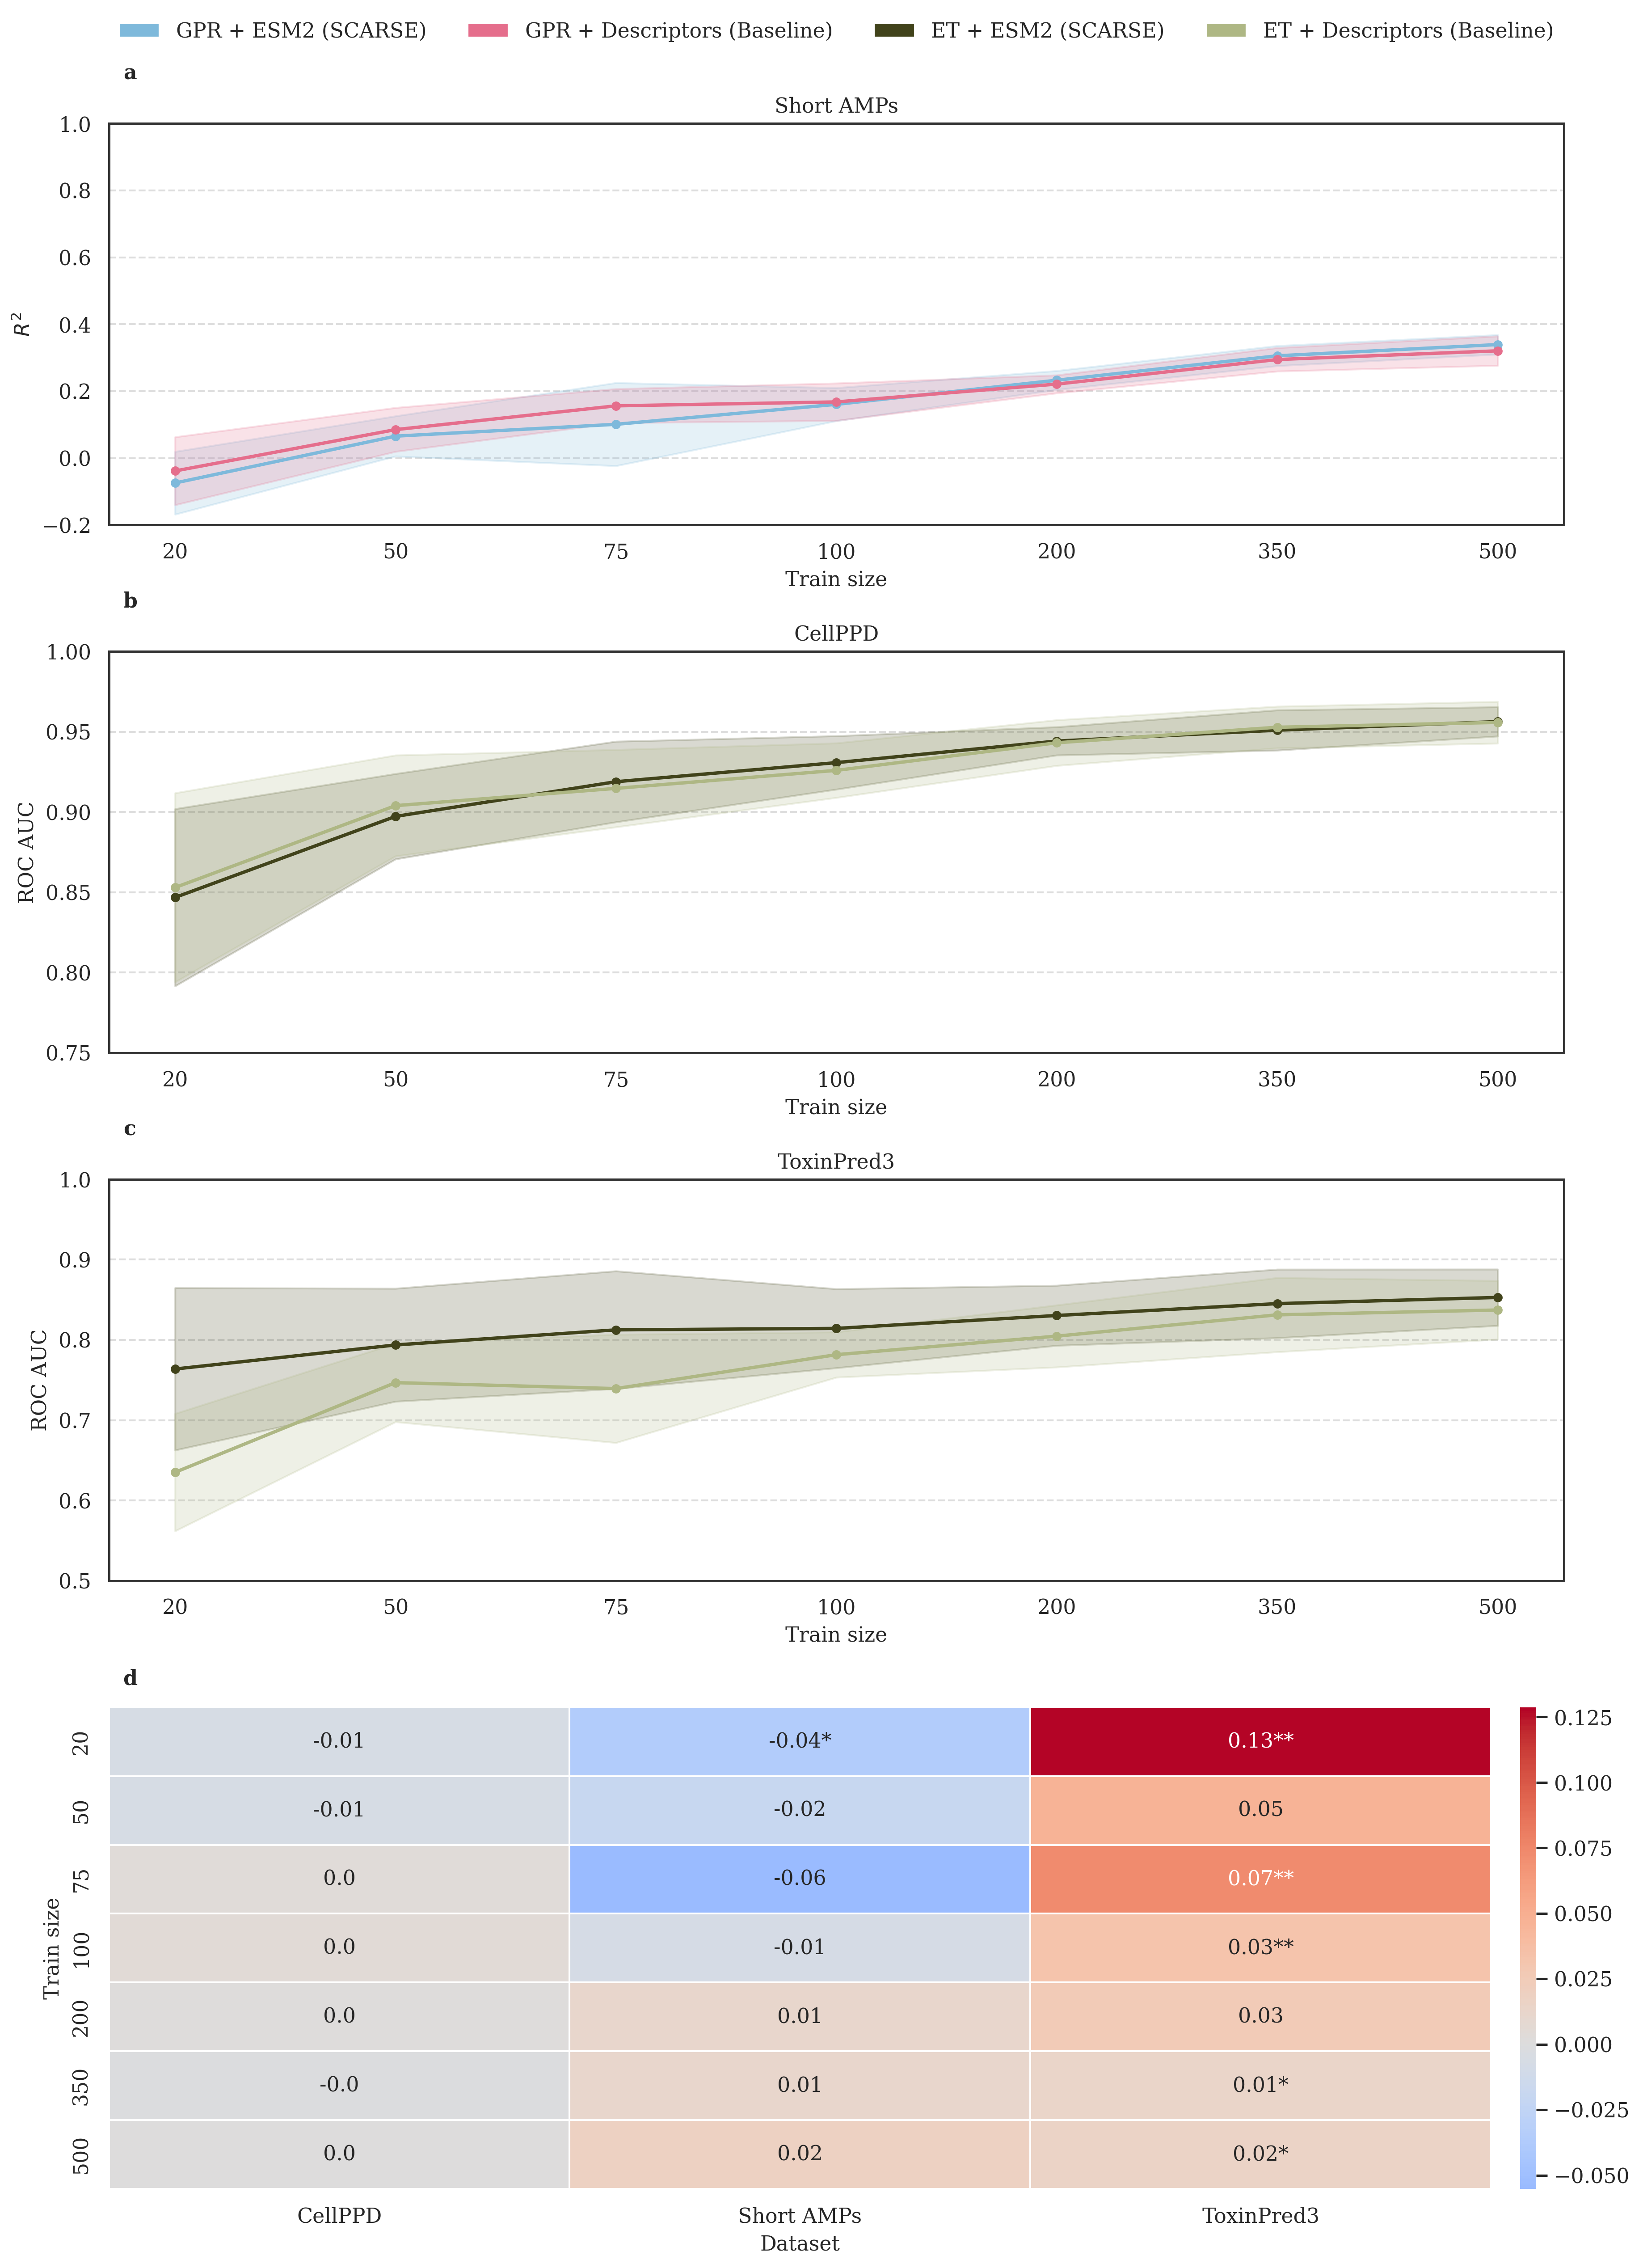

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
import string
from matplotlib.patches import Patch

sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

metric_map = {
    "mbc": ("./simulation_outputs/mbc/simulation_summary_processed.csv", "Test R2", r"Average $R^2$"),
    "cellppd": ("./simulation_outputs/cellppd/simulation_summary_processed.csv", "Test ROC AUC", "Average ROC AUC"),
    "toxinpred3": ("./simulation_outputs/toxinpred3/simulation_summary_processed.csv", "Test ROC AUC", "Average ROC AUC")
}

dataset_short = {
    "EC": "Short AMPs",
    "cellppd": "CellPPD",
    "toxinpred3": "ToxinPred3"
}

color_gpr = "#7eb9db"
color_desc = "#e56e8c"
color_et = "#41431B"
color_et_desc = "#AEB784"

letters = list(string.ascii_lowercase)

fig = plt.figure(figsize=(14, 20))

gs = GridSpec(
    4, 1,
    height_ratios=[1, 1, 1, 1.2],
    hspace=0.3
)

all_stats = []

# =========================
# PLOTS
# =========================
for i, (problem, (path, metric, ylabel)) in enumerate(metric_map.items()):

    df = pd.read_csv(path)

    if i == 0:
        models = ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"]
        colors = [color_gpr, color_desc]
    else:
        models = ["ET + ESM2 (SCARSE)", "ET + Descriptors (Baseline)"]
        colors = [color_et, color_et_desc]

    df = df[df["Model Label"].isin(models)]

    df = (
        df
        .groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
        .agg(
            mean=(f"{metric} Mean", "mean"),
            std=(f"{metric} Std", "mean")
        )
    )

    train_sizes = sorted(df["Train Size"].unique())

    x_pos = np.arange(len(train_sizes))

    ax = fig.add_subplot(gs[i, 0])

    ax.text(
        0.01, 1.15,
        letters[i],
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        fontfamily="DejaVu Serif",
        va="top",
        ha="left"
    )

    for j, model in enumerate(models):

        d = (
            df[df["Model Label"] == model]
            .set_index("Train Size")
            .reindex(train_sizes)
            .reset_index()
        )

        y = d["mean"].values
        yerr = d["std"].values
        color = colors[j]

        ax.plot(
            x_pos,
            y,
            marker='o',
            linewidth=1.8,
            markersize=4,
            color=color,
            label=model if i == 0 else None
        )

        ax.fill_between(
            x_pos,
            y - yerr,
            y + yerr,
            color=color,
            alpha=0.2
        )

    ax.set_title(dataset_short.get(df["Dataset"].iloc[0], problem))

    # =========================
    # METRIC-AWARE Y LABEL
    # =========================
    if "R^2" in ylabel:
        ax.set_ylim(-0.2, 1)
        y_axis_label = r"$R^2$"
    elif i == 1:
        ax.set_ylim(0.75, 1)
        y_axis_label = "ROC AUC"
    else:
        ax.set_ylim(0.5, 1)
        y_axis_label = "ROC AUC"
    ax.set_ylabel(y_axis_label)

    # =========================
    # X AXIS
    # =========================
    ax.set_xticks(x_pos)
    ax.set_xticklabels(train_sizes)

    ax.set_xlabel("Train size")

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

    if i == 0:
        color_map = {
            "GPR + ESM2 (SCARSE)": "#7eb9db",
            "GPR + Descriptors (Baseline)": "#e56e8c",
            "ET + ESM2 (SCARSE)": "#41431B",
            "ET + Descriptors (Baseline)": "#AEB784"
        }
        legend_handles = [Patch(facecolor=color_map[k], label=k) for k in color_map]

        ax.legend(
            handles=legend_handles,
            loc="upper center",
            ncol=4,
            bbox_to_anchor=(0.5, 1.3),
            frameon=False
        )

    stats_tmp = pd.read_csv(f"statistics/results/{problem}_results.csv")
    stats_tmp = stats_tmp[stats_tmp["Metric"] == metric]
    stats_tmp["Dataset"] = stats_tmp["Dataset"].map(dataset_short)
    all_stats.append(stats_tmp)

# =========================
# HEATMAP (UNCHANGED)
# =========================
stats = pd.concat(all_stats, ignore_index=True)

def significance_stars(p):
    if p <= 0.001:
        return "***"
    elif p <= 0.01:
        return "**"
    elif p <= 0.05:
        return "*"
    else:
        return ""

stats["signif"] = stats["p-adj"].apply(significance_stars)

effect = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="effect size",
    aggfunc="mean"
)

signif = stats.pivot_table(
    index="Train Size",
    columns="Dataset",
    values="signif",
    aggfunc="first"
)

train_sizes = sorted(effect.index)

effect = effect.reindex(train_sizes)
effect = effect[sorted(effect.columns)]

annot = effect.round(2).astype(str) + signif.fillna("")

ax_heat = fig.add_subplot(gs[3, 0])

ax_heat.text(
    0.01, 1.08,
    letters[3],
    transform=ax_heat.transAxes,
    fontsize=11,
    fontweight="bold",
    fontfamily="DejaVu Serif",
    va="top",
    ha="left"
)

effect_capped = effect.clip(upper=0.7)

sns.heatmap(
    effect_capped,
    ax=ax_heat,
    cmap="coolwarm",
    center=0,
    annot=annot,
    fmt="",
    linewidths=0.5,
    cbar_kws={
        "fraction": 0.03,
        "pad": 0.02,
        "aspect": 30
    }
)

ax_heat.set_xlabel("Dataset")
ax_heat.set_ylabel("Train size")

plt.show()

## Aggregated figure

/var/folders/hl/051_xdcn7bnfs79b2g9vrw7c0000gn/T/ipykernel_29352/2279069191.py:392: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


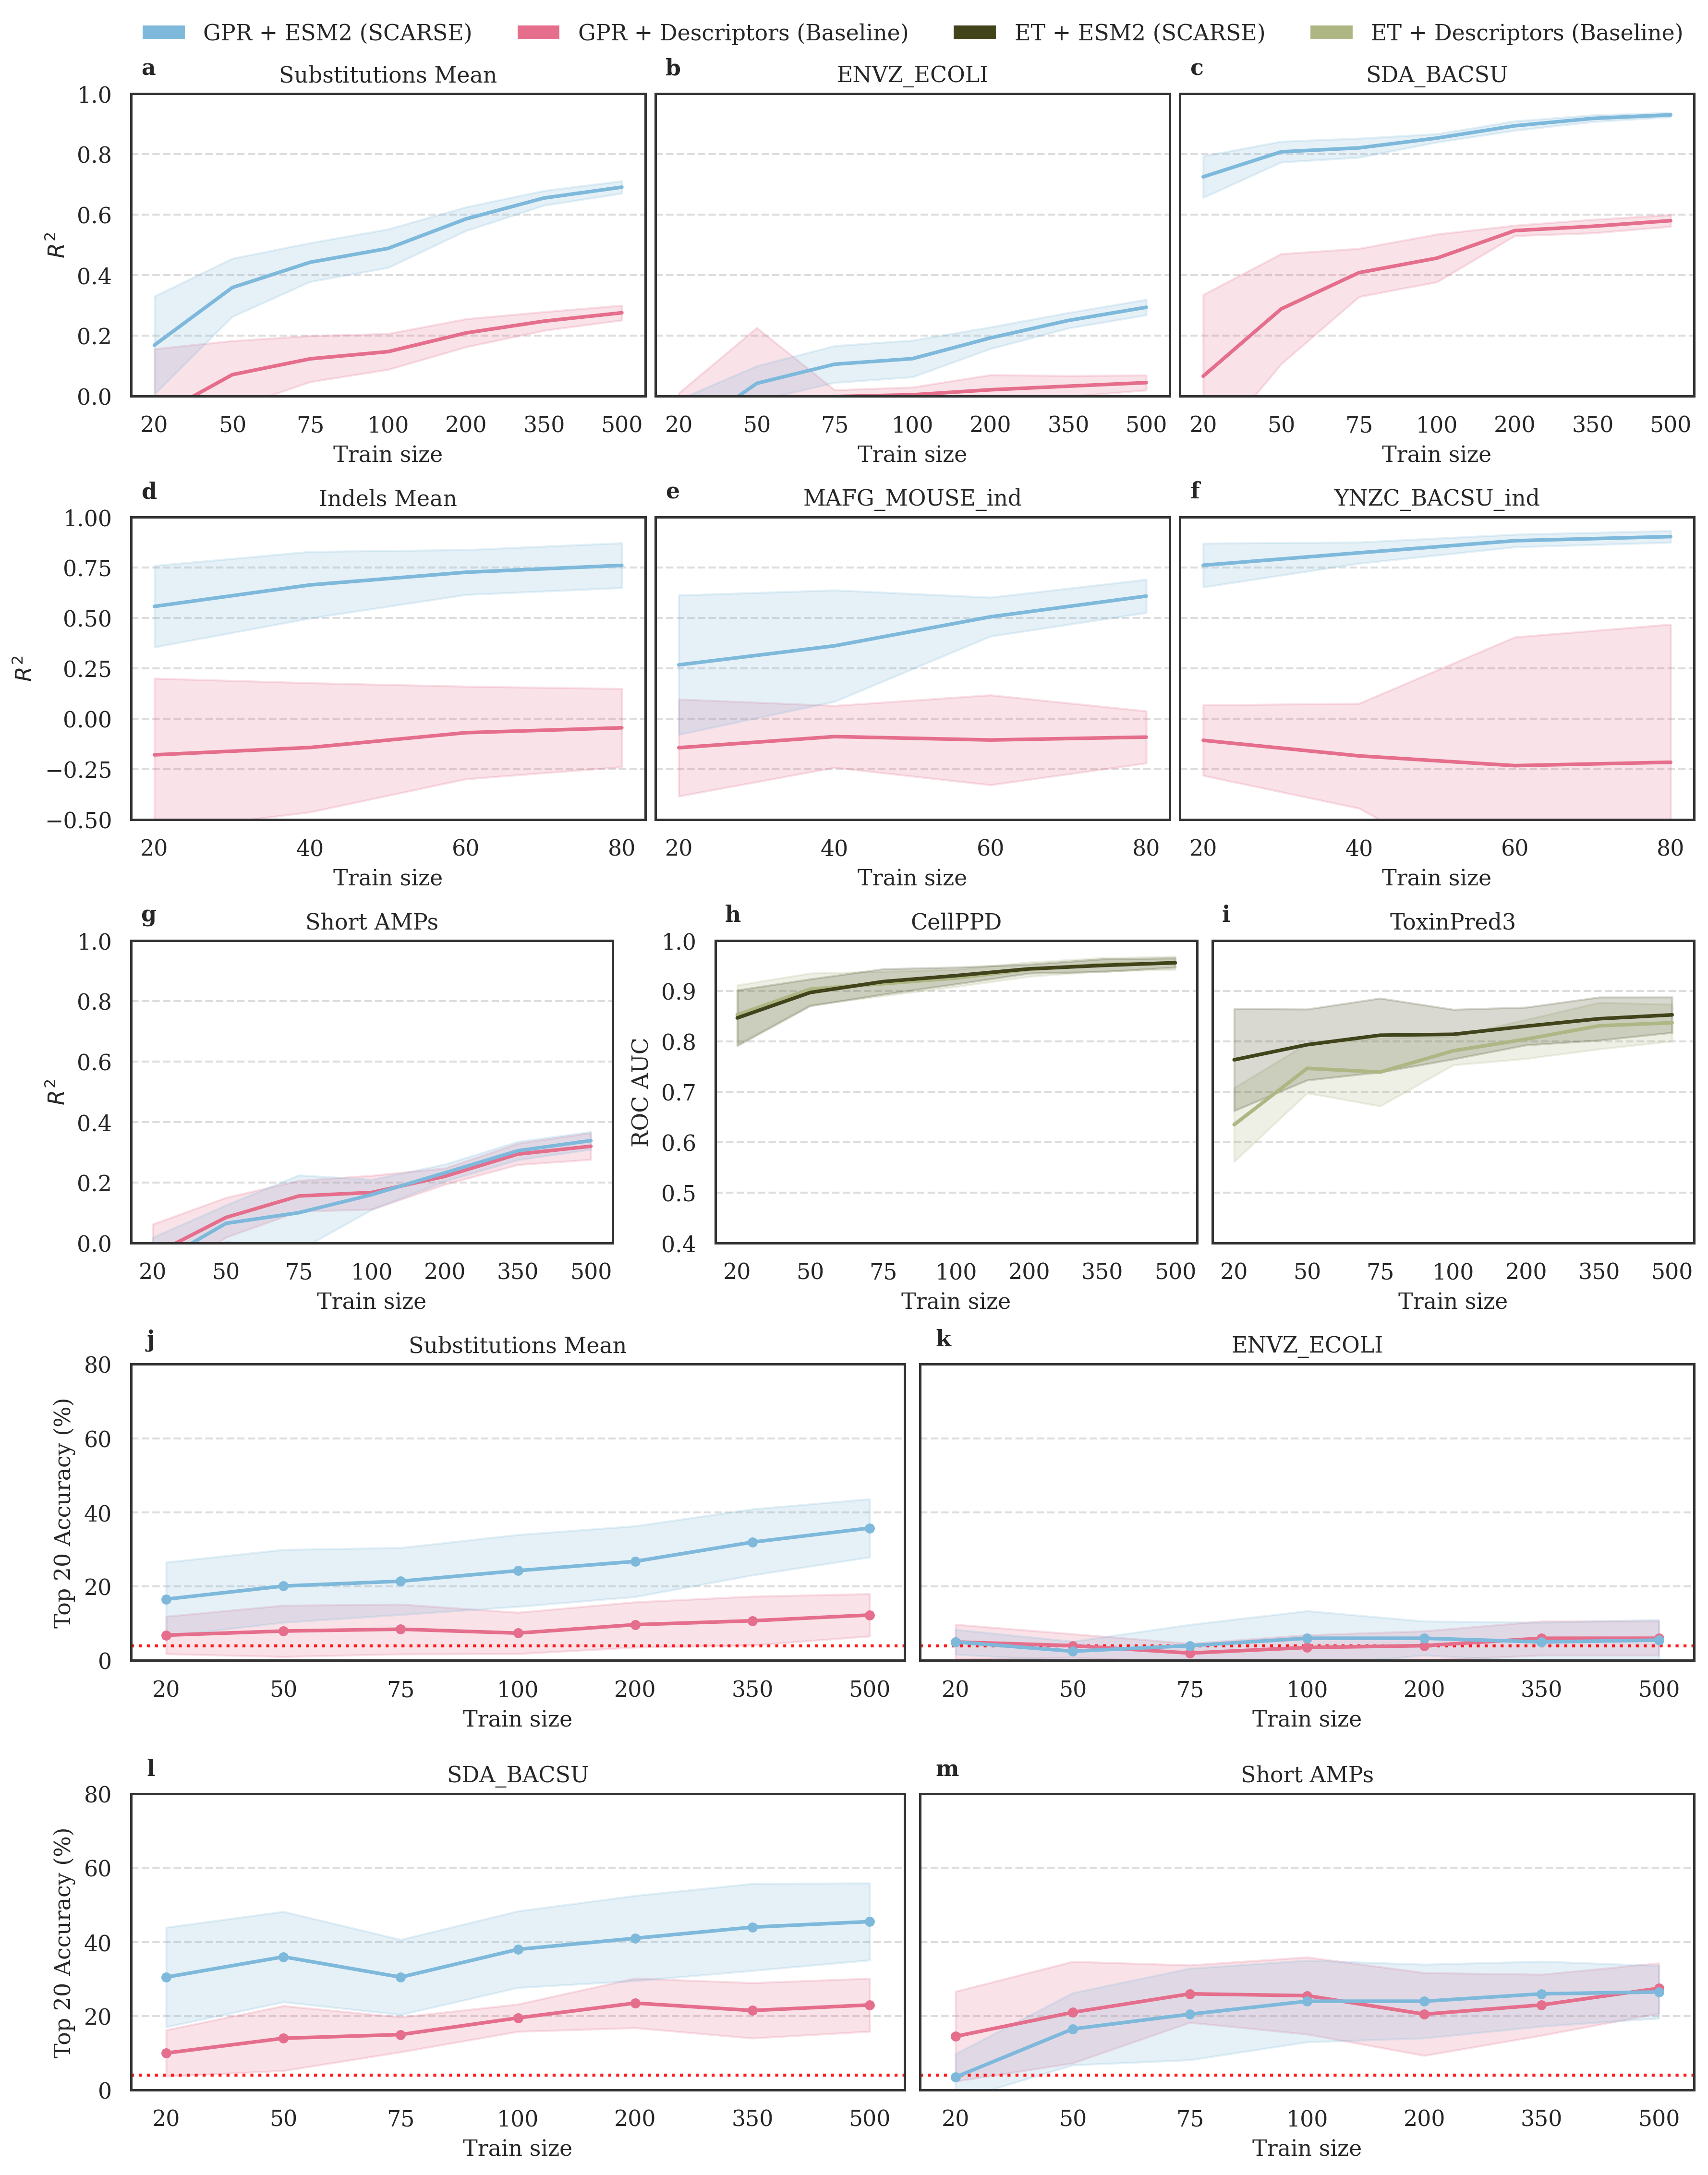

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpecFromSubplotSpec

# =========================
# STYLE
# =========================
sns.set_theme(
    context="notebook",
    style="whitegrid",
    font="DejaVu Serif",
    rc={
        "figure.dpi": 300,
        "axes.linewidth": 1.2,
        "axes.edgecolor": "#333333",
        "grid.color": "#DDDDDD",
        "grid.linestyle": "--",
        "legend.frameon": False,
    }
)

mpl.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "figure.titlesize": 11,
})

# =========================
# COLORS
# =========================
color_map = {
    "GPR + ESM2 (SCARSE)": "#7eb9db",
    "GPR + Descriptors (Baseline)": "#e56e8c",
    "ET + ESM2 (SCARSE)": "#41431B",
    "ET + Descriptors (Baseline)": "#AEB784"
}

# =========================
# DATASET NAME MAPPING
# =========================
subs_short = dict(zip(
    ["A0A247D711_LISMN_Stadelmann_2021",
     "DN7A_SACS2_Tsuboyama_2023_1JIC",
     "ENVZ_ECOLI_Ghose_2023",
     "FKBP3_HUMAN_Tsuboyama_2023_2KFV",
     "MAFG_MOUSE_Tsuboyama_2023_1K1V",
     "POLG_PESV_Tsuboyama_2023_2MXD",
     "SBI_STAAM_Tsuboyama_2023_2JVG",
     "SDA_BACSU_Tsuboyama_2023_1PV0",
     "SOX30_HUMAN_Tsuboyama_2023_7JJK",
     "YNZC_BACSU_Tsuboyama_2023_2JVD"],
    ["A0A247D711_LISMN",
     "DN7A_SACS2",
     "ENVZ_ECOLI",
     "FKBP3_HUMAN",
     "MAFG_MOUSE_sub",
     "POLG_PESV_sub",
     "SBI_STAAM",
     "SDA_BACSU",
     "SOX30_HUMAN",
     "YNZC_BACSU_sub"]
))

indel_short = dict(zip(
    ["PKN1_HUMAN_Tsuboyama_2023_1URF_indels",
     "RPC1_BP434_Tsuboyama_2023_1R69_indels",
     "POLG_PESV_Tsuboyama_2023_2MXD_indels",
     "SDA_BACSU_Tsuboyama_2023_1PV0_indels",
     "RD23A_HUMAN_Tsuboyama_2023_1IFY_indels",
     "MAFG_MOUSE_Tsuboyama_2023_1K1V_indels",
     "SQSTM_MOUSE_Tsuboyama_2023_2RRU_indels",
     "VG08_BPP22_Tsuboyama_2023_2GP8_indels",
     "YNZC_BACSU_Tsuboyama_2023_2JVD_indels",
     "PIN1_HUMAN_Tsuboyama_2023_1I6C_indels"],
    ["PKN1_HUMAN",
     "RPC1_BP434",
     "POLG_PESV_ind",
     "SDA_BACSU_ind",
     "RD23A_HUMAN",
     "MAFG_MOUSE_ind",
     "SQSTM_MOUSE",
     "VG08_BPP22",
     "YNZC_BACSU_ind",
     "PIN1_HUMAN"]
))

# =========================
# HELPERS
# =========================
def load_df(path, metric, models):
    df = pd.read_csv(path)
    df = df[df["Model Label"].isin(models)]
    return (
        df.groupby(["Dataset", "Model Label", "Train Size"], as_index=False)
        .agg(mean=(f"{metric} Mean", "mean"),
             std=(f"{metric} Std", "mean"))
    )

def compute_mean_dataset(df):
    df_gpr = df[df["Model Label"] == "GPR + ESM2 (SCARSE)"]
    df_base = df[df["Model Label"] == "GPR + Descriptors (Baseline)"]
    df_base = df_base[~df_base["Dataset"].str.contains("SDA", case=False)]
    return pd.concat([df_gpr, df_base]).groupby(
        ["Model Label", "Train Size"], as_index=False
    ).agg(mean=("mean", "mean"), std=("std", "mean"))

def best_worst_dataset(df):
    d = df[df["Model Label"] == "GPR + ESM2 (SCARSE)"]
    perf = d.groupby("Dataset")["mean"].mean()
    return perf.idxmax(), perf.idxmin()

def plot_line(ax, df, train_sizes, ylabel, ylim, title, mapping=None):
    x = np.arange(len(train_sizes))
    for m in df["Model Label"].unique():
        d = df[df["Model Label"] == m].set_index("Train Size").reindex(train_sizes).reset_index()
        y = d["mean"].values
        yerr = d["std"].values
        ax.plot(x, y, color=color_map[m], linewidth=1.8)
        ax.fill_between(x, y - yerr, y + yerr, color=color_map[m], alpha=0.2)

    ax.set_xticks(x)
    ax.set_xticklabels(train_sizes)
    ax.set_xlabel("Train size")
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)

    if mapping and title in mapping:
        title = mapping[title]

    ax.set_title(title)
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

def plot_bar(ax, df, train_sizes, ylabel, ylim, title):
    x = np.arange(len(train_sizes))
    width = 0.35

    for i, m in enumerate(df["Model Label"].unique()):
        d = df[df["Model Label"] == m].set_index("Train Size").reindex(train_sizes)
        ax.bar(x + (i - 0.5) * width, d["mean"], yerr=d["std"],
               width=width, color=color_map[m], capsize=3)

    ax.set_xticks(x)
    ax.set_xticklabels(train_sizes)
    ax.set_xlabel("Train size")
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

def plot_line_std(ax, df, train_sizes, ylabel, ylim, title):
    x = np.arange(len(train_sizes))

    for i, m in enumerate(df["Model Label"].unique()):
        d = (
            df[df["Model Label"] == m]
            .set_index("Train Size")
            .reindex(train_sizes)
            .reset_index()
        )

        y = d["mean"].values
        yerr = d["std"].values

        ax.plot(
            x, y,
            color=color_map[m],
            linewidth=1.8,
            marker='o',
            markersize=4
        )

        ax.fill_between(
            x,
            y - yerr,
            y + yerr,
            color=color_map[m],
            alpha=0.2
        )

    ax.set_xticks(x)
    ax.set_xticklabels(train_sizes)
    ax.set_xlabel("Train size")
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.grid(True, axis="y")
    ax.grid(False, axis="x")

def remove_inner_yticks(ax_grid, rows):
    for r in rows:
        for c in range(1, len(ax_grid[r])):
            ax = ax_grid[r][c]
            ax.set_ylabel("")
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)

def add_panel_letter(ax, letter, x=0.02, y=1.12):
    ax.text(
        x, y,
        letter,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        fontfamily="DejaVu Serif",
        va="top",
        ha="left"
    )

letters = list("abcdefghijklmnopqrstuvwxyz")
letter_idx = 0

# =========================
# LOAD DATA
# =========================
subs_r2 = load_df("simulation_outputs/substitutions/simulation_summary_processed.csv",
                  "Test R2", ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"])

subs_pct10 = load_df("simulation_outputs/substitutions/simulation_summary_processed.csv",
                     "Top 20 Accuracy",
                     ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"])

indels = load_df("simulation_outputs/indels/simulation_summary_processed.csv",
                 "Test R2", ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"])

mbc_r2 = load_df("simulation_outputs/mbc/simulation_summary_processed.csv",
                 "Test R2", ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"])

mbc_pct10 = load_df("simulation_outputs/mbc/simulation_summary_processed.csv",
                     "Top 20 Accuracy",
                     ["GPR + ESM2 (SCARSE)", "GPR + Descriptors (Baseline)"])

cell = load_df("simulation_outputs/cellppd/simulation_summary_processed.csv",
               "Test ROC AUC", ["ET + ESM2 (SCARSE)", "ET + Descriptors (Baseline)"])

tox = load_df("simulation_outputs/toxinpred3/simulation_summary_processed.csv",
              "Test ROC AUC", ["ET + ESM2 (SCARSE)", "ET + Descriptors (Baseline)"])

train_sizes = sorted(subs_r2["Train Size"].unique())
indel_train_sizes = [20, 40, 60, 80]

# =========================
# FIGURE
# =========================
fig = plt.figure(figsize=(14, 18))
gs = fig.add_gridspec(5, 3, wspace=0.02, hspace=0.4)

# ROWS 0–1
axes = [[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(2)]

# =========================
# ROW 3 
# =========================
row3_gs = GridSpecFromSubplotSpec(
    1, 4,
    subplot_spec=gs[2, :],
    width_ratios=[1, 0.15, 1, 1],  # spacer only between col0 and col1
    wspace=0.04
)

ax_r30 = fig.add_subplot(row3_gs[0, 0])
ax_r31 = fig.add_subplot(row3_gs[0, 2])
ax_r32 = fig.add_subplot(row3_gs[0, 3])

axes.append([ax_r30, ax_r31, ax_r32])

# =========================
# ROW 1: Substitutions
# =========================
best_subs, worst_subs = best_worst_dataset(subs_r2)

plot_line(axes[0][0], compute_mean_dataset(subs_r2), train_sizes, r"$R^2$", (0,1), "Substitutions Mean")
plot_line(axes[0][1], subs_r2[subs_r2["Dataset"] == worst_subs], train_sizes, r"$R^2$", (0,1), worst_subs, subs_short)
plot_line(axes[0][2], subs_r2[subs_r2["Dataset"] == best_subs], train_sizes, r"$R^2$", (0,1), best_subs, subs_short)

add_panel_letter(axes[0][0], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[0][1], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[0][2], letters[letter_idx]); letter_idx += 1

# =========================
# ROW 2: Indels
# =========================
best_indel, worst_indel = best_worst_dataset(indels)

plot_line(axes[1][0], compute_mean_dataset(indels), indel_train_sizes, r"$R^2$", (-0.5,1), "Indels Mean")
plot_line(axes[1][1], indels[indels["Dataset"] == worst_indel], indel_train_sizes, r"$R^2$", (-0.5,1), worst_indel, indel_short)
plot_line(axes[1][2], indels[indels["Dataset"] == best_indel], indel_train_sizes, r"$R^2$", (-0.5,1), best_indel, indel_short)

add_panel_letter(axes[1][0], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[1][1], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[1][2], letters[letter_idx]); letter_idx += 1

# =========================
# ROW 3: Mixed
# =========================
plot_line(axes[2][0], mbc_r2, train_sizes, r"$R^2$", (0,1), "Short AMPs")
plot_line(axes[2][1], cell, train_sizes, "ROC AUC", (0.4,1.0), "CellPPD")
plot_line(axes[2][2], tox, train_sizes, "ROC AUC", (0.4,1.0), "ToxinPred3")

add_panel_letter(axes[2][0], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[2][1], letters[letter_idx]); letter_idx += 1
add_panel_letter(axes[2][2], letters[letter_idx]); letter_idx += 1

remove_inner_yticks(axes, rows=[0,1])

axes[2][2].set_ylabel("")
axes[2][2].set_yticklabels([])
axes[2][2].tick_params(axis='y', length=0)

# =========================
# BOTTOM GRID
# =========================
sub_gs = GridSpecFromSubplotSpec(
    2, 2,
    subplot_spec=gs[3:5, :],
    wspace=0.02,
    hspace=0.45
)

ax_b00 = fig.add_subplot(sub_gs[0, 0])
ax_b01 = fig.add_subplot(sub_gs[0, 1])
ax_b10 = fig.add_subplot(sub_gs[1, 0])
ax_b11 = fig.add_subplot(sub_gs[1, 1])

for ax in [ax_b00, ax_b01, ax_b10, ax_b11]:
    ax.axhline(
        y=4,
        color="red",
        linestyle=":",
        linewidth=1.5,
        alpha=0.9
    )

#plot_bar(ax_b00, compute_mean_dataset(subs_pct10), train_sizes, "", (0,100), "Mean (subs)")
#plot_bar(ax_b01, subs_pct10[subs_pct10["Dataset"] == worst_subs], train_sizes, "", (0,100),
#         subs_short.get(worst_subs, worst_subs))
#plot_bar(ax_b10, subs_pct10[subs_pct10["Dataset"] == best_subs], train_sizes, "", (0,100),
#         subs_short.get(best_subs, best_subs))
#plot_bar(ax_b11, mbc_pct10[mbc_pct10["Dataset"] == "EC"], train_sizes, "", (0,100), "Short AMPs")

plot_line_std(ax_b00, compute_mean_dataset(subs_pct10), train_sizes, "Top 20 Accuracy (%)", (0,80), "Substitutions Mean")
plot_line_std(ax_b01, subs_pct10[subs_pct10["Dataset"] == worst_subs], train_sizes, "", (0,80),
              subs_short.get(worst_subs, worst_subs))
plot_line_std(ax_b10, subs_pct10[subs_pct10["Dataset"] == best_subs], train_sizes, "Top 20 Accuracy (%)", (0,80),
              subs_short.get(best_subs, best_subs))
plot_line_std(ax_b11, mbc_pct10[mbc_pct10["Dataset"] == "EC"], train_sizes, "", (0,80), "Short AMPs")

add_panel_letter(ax_b00, letters[letter_idx]); letter_idx += 1
add_panel_letter(ax_b01, letters[letter_idx]); letter_idx += 1
add_panel_letter(ax_b10, letters[letter_idx]); letter_idx += 1
add_panel_letter(ax_b11, letters[letter_idx]); letter_idx += 1

for ax in [ax_b01, ax_b11]: 
    ax.set_ylabel("") 
    ax.set_yticklabels([]) 
    ax.tick_params(axis='y', length=0)

bottom_axes = [ax_b00, ax_b01, ax_b10, ax_b11]

#y_center = (ax_b00.get_position().y0 + ax_b10.get_position().y1) / 2

#fig.text(
#    0.082,
#    y_center,
#    "Top 20 accuracy (%)",
#    va="center",
#    rotation="vertical",
#    fontsize=11
#)

legend_handles = [Patch(facecolor=color_map[k], label=k) for k in color_map]

axes[0][1].legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.3)
)

plt.tight_layout()

plt.savefig("benchmark_results.png", dpi=300, bbox_inches='tight')
plt.savefig("benchmark_results.pdf", bbox_inches='tight')

plt.show()